In [ ]:
# !pip install tensorflow

In [7]:
import sys
print(sys.executable)

/run/media/suko-magar/Local Disk/ML with Python/Data Seience and ML/COURSE/.venv/bin/python


In [8]:
import tensorflow as tf
tf.__version__

'2.21.0'

---

In [9]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [10]:
data = pd.read_csv("Iris.csv", index_col="Id")
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
Id,,,,,
1,5.1,3.5,1.4,0.2,Iris-setosa
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa


In [11]:
X = data.drop("Species", axis=1).to_numpy()
y = data[["Species"]].to_numpy()

In [12]:
scaler = StandardScaler()
onehot = OneHotEncoder(sparse_output=False)

scaled_X = scaler.fit_transform(X)
enc_y = onehot.fit_transform(y)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    scaled_X, enc_y, test_size=0.2, shuffle=True, stratify=enc_y, random_state=899
)

## Model Creation and Compile

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.initializers import RandomNormal

In [15]:
inp_shape = X_test.shape[1]
num_classes = y_train.shape[1]

In [16]:
initialize = RandomNormal()

In [17]:
model = Sequential()

model.add(Input(shape= (inp_shape, ))) #<- Input Layer

model.add(Dense(32, activation="relu")) #- Hidden Layer
model.add(Dense(16, activation="tanh")) #- Hidden Layer

model.add(Dense(num_classes, activation="softmax")) #<- Output layer


model.compile(
    optimizer = "Adam", loss = "categorical_crossentropy", metrics = ["accuracy"]
)

E0000 00:00:1780812490.353600   53790 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


```Input shape (4 features ) + 1 bias -> 5 x 16 -> 80 weights```

```Same for other layers, except for output layer```

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 739 (2.89 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history = model.fit(
    X_train, y_train, epochs = 50, batch_size = 32
)

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2833 - loss: 1.1067 
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4167 - loss: 1.0285
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5583 - loss: 0.9583
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6750 - loss: 0.8944
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6917 - loss: 0.8356
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7000 - loss: 0.7874
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7250 - loss: 0.7442
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7667 - loss: 0.7062
Epoch 9/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7917 - loss: 0.6717
Epoch 10/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7917 - loss: 0.6402
Epoch 11/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7917 - loss: 0.6113 
Epoch 12/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8000 - loss: 0.5855 


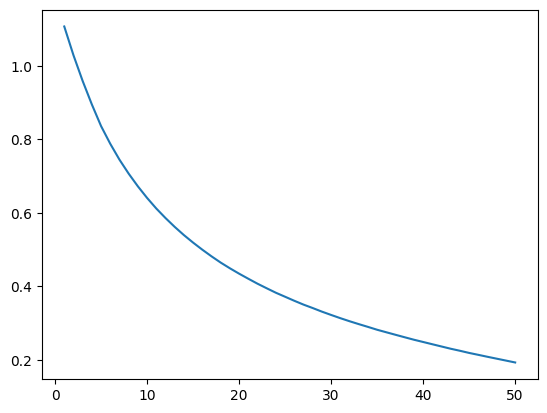

In [20]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
loss = history.history['loss']

# plt.plot(range(1,51), acc)
plt.plot(range(1,51), loss)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,219 (8.67 KB)

 Trainable params: 739 (2.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,480 (5.79 KB)

In [22]:
loss, acc = model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - accuracy: 0.9667 - loss: 0.2008


In [23]:
acc

0.9666666388511658

In [24]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


In [25]:
y_pred, y_true

(array([1, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 1, 0, 0, 0, 2, 1, 2, 2, 1, 1, 1,
        1, 0, 0, 1, 1, 1, 1, 2]),
 array([1, 2, 0, 2, 0, 0, 2, 2, 2, 0, 0, 1, 0, 0, 0, 2, 1, 2, 2, 1, 1, 1,
        1, 0, 0, 1, 1, 1, 2, 2]))

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, auc

In [27]:
confusion_matrix(y_true, y_pred)

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  1,  9]])

In [28]:
onehot.categories_

[array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)]

In [29]:
f1_score(y_true, y_pred, average = "micro")

0.9666666666666667

In [30]:
model.save("iris_classifier.keras")

In [31]:
import pickle

In [32]:
to_package = {
    "scaler" : scaler,
    "encoder" : onehot,
    "model" : model
}

with open("iris_classifier.pkl", "wb") as file:
    pickle.dump(to_package, file)